In [87]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [36]:
# Disk Diameter (mm)
data_inertia = {
    'Disk Diameter':[31.70,31.68,31.70,31.70,31.70],
    'Mass Holder Diameter':[31.58,31.58,31.60,31.58,31.60]
}
df_inertia = pd.DataFrame(data_inertia)
df_inertia.index += 1 # Index number is now trial number
print(df_inertia)
caliper_precision_error = 0.02
error_disk_diameter = max(df_inertia['Disk Diameter'].sem(), caliper_precision_error)
error_holder_diameter = max(df_inertia['Mass Holder Diameter'].sem(), caliper_precision_error)
mean_disk_diameter = df_inertia['Disk Diameter'].mean()
mean_holder_diameter = df_inertia['Mass Holder Diameter'].mean()
print(f'Disk Diameter: {mean_disk_diameter:.2f} +- {error_disk_diameter:.2f}')
print(f'Holder Diameter: {mean_holder_diameter.mean():.2f} +- {error_holder_diameter:.2f}')

   Disk Diameter  Mass Holder Diameter
1          31.70                 31.58
2          31.68                 31.58
3          31.70                 31.60
4          31.70                 31.58
5          31.70                 31.60
Disk Diameter: 31.70 +- 0.02
Holder Diameter: 31.59 +- 0.02


In [59]:
I_holder = 0.125 * 50 * (mean_holder_diameter**2)
I_holder_error = I_holder * np.sqrt(4*(error_holder_diameter/mean_holder_diameter)**2
                                    +(1/50)**2)
I_disk = 0.125 * 20 * (mean_disk_diameter**2)
I_disk_error = I_holder * np.sqrt(4*(error_disk_diameter/mean_disk_diameter)**2
                                    +(1/20)**2)
print(f'I_Disk: {I_disk:.2f} +- {I_disk_error:.2f}')
print(f'I_Holder: {I_holder:.2f} +- {I_holder_error:.2f}')

I_Disk: 2511.59 +- 311.91
I_Holder: 6236.26 +- 124.97


In [60]:
# Number of Disks vs Oscillation Time for 10 periods (s)
data_oscillations = {
    0:[12.39,12.27,12.23,12.15,12.36],
    1:[15.03,15.23,15.14,15.05,15.30],
    3:[19.33,19.14,19.81,19.60,19.38],
    5:[22.72,23.14,22.64,22.90,22.90],
    7:[26.05,26.55,26.32,25.72,26.38],
    9:[29.15,28.57,28.52,28.49,28.30]
}
df_oscillations = pd.DataFrame(data_oscillations)
df_oscillations.index += 1 # The index number is the trial number
print(df_oscillations)
ten_period_averages = np.array([df_oscillations[x].mean() for x in range(10) if (x == 0 or x % 2 == 1)])
ten_period_errors = np.array([max(df_oscillations[x].sem(),0.01) for x in range(10) if (x == 0 or x % 2 == 1)])
print(f'With 0 Disks: {ten_period_averages[0]:.2f} +- {ten_period_errors[0]:.2f} s \n')
for i in range(1,6):
    print(f'With {i*2 - 1} Disks: {ten_period_averages[i]:.2f} +- {ten_period_errors[i]:.2f} s \n')

       0      1      3      5      7      9
1  12.39  15.03  19.33  22.72  26.05  29.15
2  12.27  15.23  19.14  23.14  26.55  28.57
3  12.23  15.14  19.81  22.64  26.32  28.52
4  12.15  15.05  19.60  22.90  25.72  28.49
5  12.36  15.30  19.38  22.90  26.38  28.30
With 0 Disks: 12.28 +- 0.04 s 

With 1 Disks: 15.15 +- 0.05 s 

With 3 Disks: 19.45 +- 0.12 s 

With 5 Disks: 22.86 +- 0.09 s 

With 7 Disks: 26.20 +- 0.15 s 

With 9 Disks: 28.61 +- 0.14 s 



In [117]:
moments_of_inertia = np.array([I_holder + x*I_disk for x in range(10) if (x==0 or x%2==1)])
moments_of_inertia_errors = np.sqrt(np.array([(I_holder_error)**2 + (x*I_disk_error)**2 for x in range(10) if (x==0 or x%2==1)]))
periods_squared = (ten_period_averages/10)**2
periods_squared_errors = periods_squared*(2*ten_period_errors/ten_period_averages)
data_convenience = pd.DataFrame()
data_convenience['Period-Square'] = periods_squared
data_convenience['Period-Square Errors'] = periods_squared_errors
data_convenience['Moments of Inertia'] = moments_of_inertia
data_convenience['MoI Errors'] = moments_of_inertia_errors
data_convenience.index = data_convenience.index*2 - 1
data_convenience.rename(index={-1:0},inplace=True) # Index Number is now Number of Disks
print(data_convenience)

   Period-Square  Period-Square Errors  Moments of Inertia   MoI Errors
0       1.507984              0.010705          6236.26090   124.974968
1       2.295225              0.015657          8747.85194   336.017940
3       3.783803              0.044991         13771.03402   944.045848
5       5.225796              0.039542         18794.21610  1564.561145
7       6.866496              0.076138         23817.39818  2186.960242
9       8.183032              0.082087         28840.58026  2809.991659


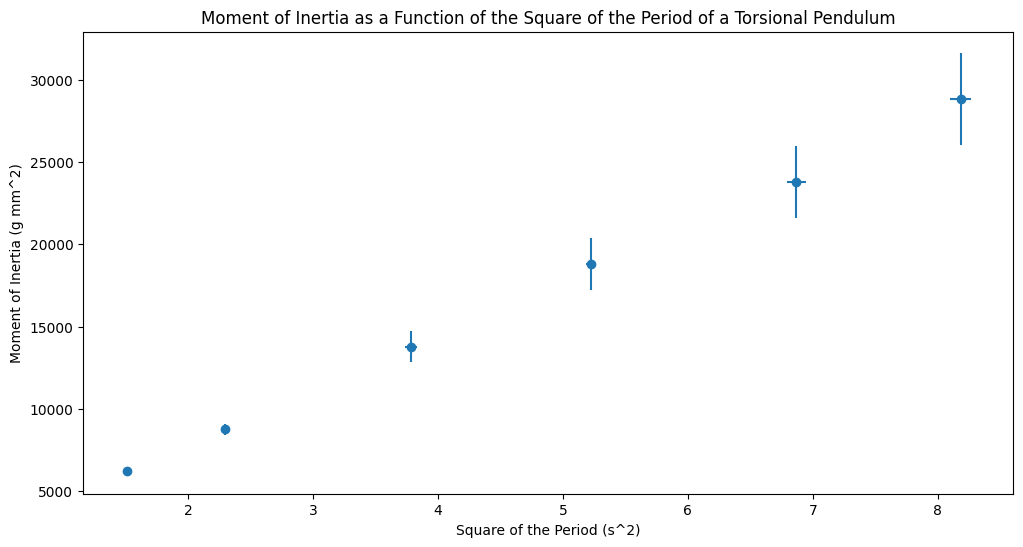

In [107]:
plt.figure(figsize=(12,6))
plt.errorbar(x=periods_squared, y=moments_of_inertia,xerr=periods_squared_errors,yerr=moments_of_inertia_errors,fmt='o')
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Moment of Inertia (g mm^2)")
plt.title("Moment of Inertia as a Function of the Square of the Period of a Torsional Pendulum")
plt.show()

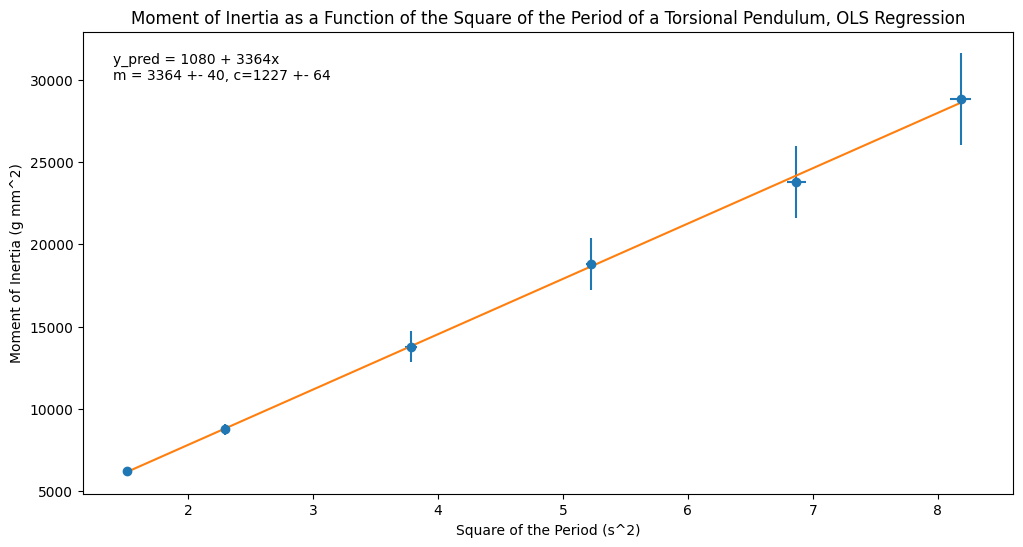

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     7161.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.17e-07
Time:                        13:50:29   Log-Likelihood:                -39.963
No. Observations:                   6   AIC:                             83.93
Df Residuals:                       4   BIC:                             83.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1080.4223    207.373      5.210      0.0

C:\Users\vijay\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [124]:
y = moments_of_inertia
X = periods_squared
X = sm.add_constant(X)
ols_model = sm.OLS(y,X)
ols_results = ols_model.fit()
plt.figure(figsize=(12,6))
plt.errorbar(x=periods_squared, y=moments_of_inertia,xerr=periods_squared_errors,yerr=moments_of_inertia_errors,fmt='o')
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Moment of Inertia (g mm^2)")
plt.title("Moment of Inertia as a Function of the Square of the Period of a Torsional Pendulum, OLS Regression")
plt.plot(periods_squared, ols_results.predict())
plt.text(1.4, 31000, f'y_pred = {ols_results.params[0]:.0f} + {ols_results.params[1]:.0f}x')
plt.text(1.4, 30000, f'm = {ols_results.params[1]:.0f} +- {ols_results.bse[1]:.0f}, c={wls_results.params[0]:.0f} +- {wls_results.bse[0]:.0f}')

plt.show()
print(ols_results.summary())

In [118]:
adjusted_moi_errors = np.sqrt(moments_of_inertia_errors**2 + (ols_results.params[1]*periods_squared_errors)**2)
data_convenience['Adjusted MoI Errors'] = adjusted_moi_errors
print(data_convenience[['Period-Square', 'Moments of Inertia', 'Adjusted MoI Errors']])

   Period-Square  Moments of Inertia  Adjusted MoI Errors
0       1.507984          6236.26090           130.059896
1       2.295225          8747.85194           340.120312
3       3.783803         13771.03402           956.100008
5       5.225796         18794.21610          1570.205092
7       6.866496         23817.39818          2201.906166
9       8.183032         28840.58026          2823.526109


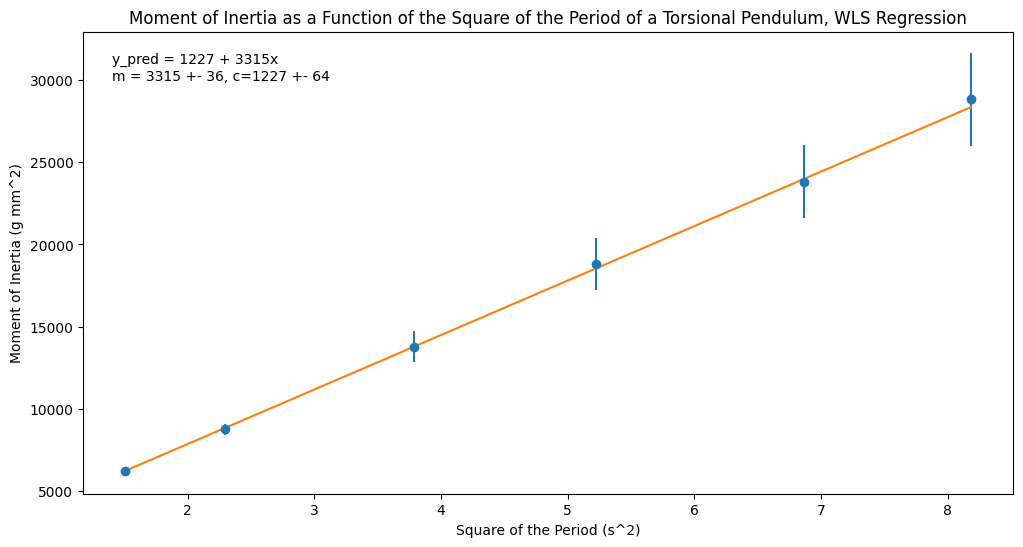

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            WLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     8538.
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           8.22e-08
Time:                        13:50:10   Log-Likelihood:                -37.645
No. Observations:                   6   AIC:                             79.29
Df Residuals:                       4   BIC:                             78.87
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1227.0428     64.480     19.030      0.0

C:\Users\vijay\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [123]:
wls_model = sm.WLS(y,X,weights=1/(adjusted_moi_errors**2))
wls_results = wls_model.fit()
plt.figure(figsize=(12,6))
plt.errorbar(x=periods_squared, y=moments_of_inertia,yerr=adjusted_moi_errors,fmt='o')
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Moment of Inertia (g mm^2)")
plt.title("Moment of Inertia as a Function of the Square of the Period of a Torsional Pendulum, WLS Regression")
plt.plot(periods_squared, wls_results.predict())
plt.text(1.4, 31000, f'y_pred = {wls_results.params[0]:.0f} + {wls_results.params[1]:.0f}x')
plt.text(1.4, 30000, f'm = {wls_results.params[1]:.0f} +- {wls_results.bse[1]:.0f}, c={wls_results.params[0]:.0f} +- {wls_results.bse[0]:.0f}')
plt.show()
print(wls_results.summary())

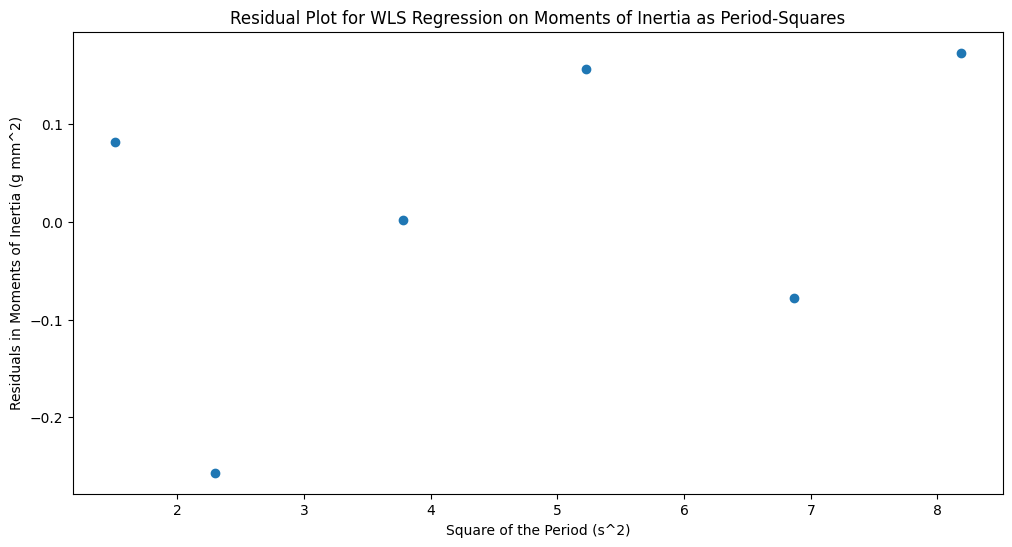

In [127]:
wls_residuals = (y - wls_results.predict())/adjusted_moi_errors
plt.figure(figsize=(12,6))
plt.scatter(x=periods_squared, y=wls_residuals)
plt.xlabel("Square of the Period (s^2)")
plt.ylabel("Residuals in Moments of Inertia (g mm^2)")
plt.title("Residual Plot for WLS Regression on Moments of Inertia as Period-Squares")
plt.show()

In [130]:
kappa = 4 * np.pi**2 * wls_results.params[1]
kappa_error = 4 * np.pi**2 * wls_results.bse[1]
print(f'Slope: {wls_results.params[1]:.0f} +- {wls_results.bse[1]:.0f}')
print(f'Kappa: {kappa:.0f} +- {kappa_error:.0f}')

Slope: 3315 +- 36
Kappa: 130861 +- 1416
